In [6]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import random

In [7]:
class Value:

    def __init__(self,data, _children = (), _op='', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda:None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data, (self,other),'+')
        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward=_backward
        return out

    def __radd__(self, other):   # other + self
        return self + other

    def __neg__(self):
        return self * -1

    def __sub__(self,other):
        return self + (-other)

    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data, (self,other),'*')
        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward=_backward
        return out

    def __rmul__(self,other):
        return self * other

    def __truediv__(self,other):
        return self * other**-1

    def __pow__(self,other):
        assert isinstance(other,(int,float)),"only supporting int float power for now"
        out = Value(self.data ** other,(self,),f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other -1)) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x=self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t,(self,),'tanh')
        def _backward():
            self.grad += (1-t**2)*out.grad
        out._backward=_backward
        return out

    def exp(self):
        x=self.data
        out = Value(math.exp(x),(self,),'exp')
        def _backward():
            self.grad += math.exp(x) * out.grad
        out._backward=_backward
        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [8]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # a rectangular node for each Value
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is the result of an op, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


In [79]:
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.8813735870195432,label='b')

x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1x2w2'
n = x1w1x2w2 + b; n.label= 'n'
o=n.tanh(); o.label = 'o'

In [80]:
o.backward()

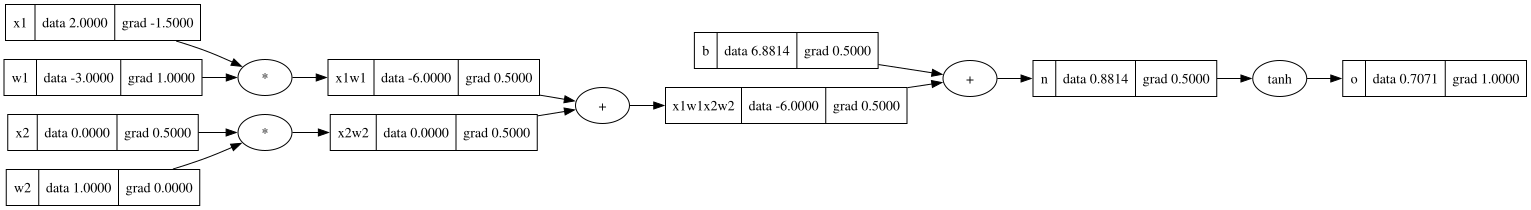

In [81]:
draw_dot(o)

In [92]:
import torch

In [93]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print (o.data.item())
o.backward()

print('----------')
print(x2.grad.item())
print(w2.grad.item())
print(x1.grad.item())
print(w1.grad.item())

0.7071066904050358
----------
0.5000001283844369
0.0
-1.5000003851533106
1.0000002567688737


In [88]:
torch.Tensor([[1,2,3],[4,5,6]])

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [95]:
o.item()

0.7071066904050358

In [96]:
o.data.item()

0.7071066904050358

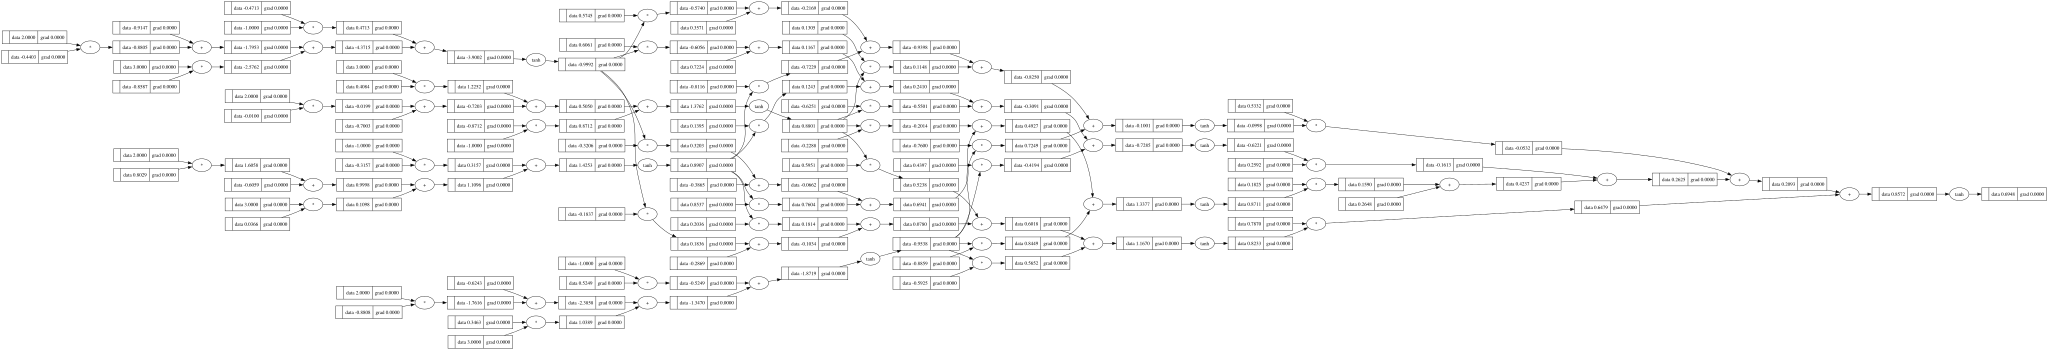

In [8]:
draw_dot(n(x))

In [ ]:
class Neuron:

    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        

class MLP:
    def __init__(self,nin,nout
                 s):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

In [ ]:
x=[2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)

In [149]:
xs=[
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys = [1.0,-1.0,-1.0,1.0] # Desired output

In [ ]:
for k in range(20):
    #Forward Pass
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt) ** 2 for ygt,yout in zip(ys,ypred)])

    #Backward pass
    for p in n.parameters():  #Flush the grad on every backward pass zero.backward() in pytorch
        p.grad = 0.0
    loss.backward()
    

    #update
    for p in n.parameters():
        p.data += -0.05 * p.grad
    print(k,loss.data)

In [10]:
n = MLP(2,[2,1])

In [12]:
xs = [
    [0.0,0.0],
    [0.0,1.0],
    [1.0,0.0],
    [1.0,1.0]
]
ys = [0.0,1.0,1.0,0.0]

In [95]:
for k in range(50):
    #Forward Pass
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt,yout in zip(ys,ypred)])

    #Backward PAss
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.09 * p.grad
    print(k,loss.data)

0 0.002354450617631042
1 0.0023475820859259326
2 0.0023407508305830853
3 0.0023339565589509865
4 0.0023271989813686196
5 0.0023204778111279144
6 0.002313792764436837
7 0.0023071435603829534
8 0.0023005299208976007
9 0.002293951570720499
10 0.0022874082373649726
11 0.002280899651083607
12 0.0022744255448345035
13 0.0022679856542478683
14 0.002261579717593262
15 0.0022552074757472376
16 0.002248868672161409
17 0.002242563052831081
18 0.0022362903662642626
19 0.002230050363451153
20 0.002223842797834021
21 0.0022176674252776083
22 0.002211524004039846
23 0.0022054122947431135
24 0.0021993320603457397
25 0.0021932830661141
26 0.0021872650795949594
27 0.0021812778705882774
28 0.002175321211120377
29 0.0021693948754175265
30 0.002163498639879821
31 0.0021576322830554784
32 0.0021517955856155133
33 0.002145988330328725
34 0.002140210302037058
35 0.002134461287631262
36 0.0021287410760269607
37 0.0021230494581410122
38 0.002117386226868176
39 0.0021117511770581453
40 0.002106144105492848
41 0.

In [92]:
n.parameters()[0].data

-2.313676483399078

In [94]:
print("\nFinal Predictions:")
for x in xs:
    pred = n(x).data
    print(f"Input: {x} | Prediction: {pred:.4f} (~{round(pred)})")


Final Predictions:
Input: [0.0, 0.0] | Prediction: 0.0020 (~0)
Input: [0.0, 1.0] | Prediction: 0.9657 (~1)
Input: [1.0, 0.0] | Prediction: 0.9659 (~1)
Input: [1.0, 1.0] | Prediction: 0.0035 (~0)


In [96]:
print("\nFinal Predictions:")
for x in xs:
    pred = n(x).data
    print(f"Input: {x} | Prediction: {pred:.4f} (~{round(pred)})")


Final Predictions:
Input: [0.0, 0.0] | Prediction: 0.0017 (~0)
Input: [0.0, 1.0] | Prediction: 0.9680 (~1)
Input: [1.0, 0.0] | Prediction: 0.9681 (~1)
Input: [1.0, 1.0] | Prediction: 0.0030 (~0)
